# Diffusion Map on GXY configurations

This notebook loads GXY-model configurations saved via `build_gxy_dataset` in `gxy_sim.py`, builds a feature matrix, and runs a diffusion map embedding to visualize the temperature manifold.

In [2]:
# Load XY dataset and metadata produced by the simulator
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Path to the compressed dataset produced by build_xy_dataset
DATA_PATH = Path('gxy_dataset.npz')
METADATA_PATH = Path('gxy_dataset.metadata.json')

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset {DATA_PATH} not found. Update DATA_PATH to point to your file.")
if not METADATA_PATH.exists():
    raise FileNotFoundError(f"Metadata file {METADATA_PATH} not found.")

with np.load(DATA_PATH) as npz:
    configurations = npz['configurations']

with open(METADATA_PATH, 'r', encoding='utf-8') as f:
    metadata = json.load(f)

num_samples, num_sites = configurations.shape
print(f"Loaded {num_samples} samples with {num_sites} lattice sites each.")


Loaded 12500 samples with 1024 lattice sites each.


In [3]:
# Build 2D (cos, sin) features per site for diffusion-map input
angles = configurations.astype(np.float64)
features = np.stack([np.cos(angles), np.sin(angles)], axis=-1)
features = features.reshape(num_samples, -1)
print(f"Feature matrix shape: {features.shape}")

# Extract temperatures for coloring and later aggregation
temperatures = np.array([entry['temperature'] for entry in metadata], dtype=np.float64)
deltas = np.array([entry['delta'] for entry in metadata], dtype=np.float64)
assert temperatures.shape[0] == num_samples
assert deltas.shape[0] == num_samples


Feature matrix shape: (12500, 2048)


In [3]:
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import normalize

# Baseline diffusion map using Euclidean distance on (cos, sin) features
def diffusion_map(data, epsilon=None, n_components=10):
    # Pairwise Euclidean distances
    dists = pairwise_distances(data, metric='euclidean')
    if epsilon is None:
        # median of squared distances as heuristic bandwidth
        eps = np.median(dists ** 2)
        epsilon = max(eps, 1e-12)
    kernel = np.exp(-(dists ** 2) / epsilon)
    # Normalize to Markov matrix
    row_sums = kernel.sum(axis=1, keepdims=True)
    P = kernel / row_sums
    # Symmetrize for stable eigendecomposition
    D_half = np.sqrt(row_sums)
    A = kernel / (D_half @ D_half.T)
    # Eigen decomposition
    eigvals, eigvecs = np.linalg.eigh(A)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    # Skip the first eigenvector (constant mode)
    diffusion_coords = eigvecs[:, 1:n_components+1]
    diffusion_vals = eigvals[1:n_components+1]
    # Normalize coordinates by eigenvalues (diffusion map convention)
    diffusion_coords = diffusion_coords * diffusion_vals
    return diffusion_coords, diffusion_vals, epsilon

embeddings, lambdas, eps = diffusion_map(features, n_components=10)
print('Eigenvalues:', lambdas)
print('Epsilon used:', eps)


Eigenvalues: [0.24166801 0.21440277 0.04835219 0.04504384 0.04403851 0.04246646
 0.0386692  0.03494054 0.02981054 0.02657811]
Epsilon used: 799.9693867555285


In [4]:
import numpy as np
from sklearn.preprocessing import normalize

# Use O(2)-invariant distance so embeddings respect global rotations/reflections
angles = configurations.astype(np.float64)       # shape: (num_samples, N_sites)
num_samples, num_sites = angles.shape
print(f"Angles matrix shape: {angles.shape}")

temperatures = np.array([entry['temperature'] for entry in metadata],
                        dtype=np.float64)
assert temperatures.shape[0] == num_samples

# Diffusion map using the O(2)-invariant distance between XY configurations.
def diffusion_map_O2_invariant(angles, epsilon=None, n_components=10):
    n_samples, n_sites = angles.shape

    # Complex spin representation z = exp(i theta)
    Z = np.exp(1j * angles)           # shape: (n_samples, n_sites)

    # S_{ij} = sum_k exp(i (theta_k^i - theta_k^j))
    #        = Z[i] dot conj(Z[j])
    S1 = Z @ Z.conj().T                # shape: (n_samples, n_samples)
    S2 = Z @ Z.T                       # shape: (n_samples, n_samples)

    # O(2)-invariant squared distances: d^2_ij = 2N - 2|S_ij|
    d2 = 2.0 * n_sites - 2.0 * np.maximum(np.abs(S1), np.abs(S2))   # real, nonnegative

    # Choose epsilon from median of d^2 if not provided
    if epsilon is None:
        eps = np.median(d2)
        epsilon = max(eps, 1e-12)

    # Gaussian kernel in terms of squared distance
    kernel = np.exp(-d2 / epsilon)

    # Row sums for Markov normalization
    row_sums = kernel.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0

    # Markov matrix P (right-stochastic)
    P = kernel / row_sums

    # Symmetrize using the usual diffusion-map trick
    D_half = np.sqrt(row_sums)
    A = kernel / (D_half @ D_half.T)   # symmetric similarity

    # Eigen-decomposition of A
    eigvals, eigvecs = np.linalg.eigh(A)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    # Skip the trivial constant mode (first eigenvector)
    diffusion_vals = eigvals[1:n_components+1]
    diffusion_coords = eigvecs[:, 1:n_components+1]

    # Diffusion map coordinates: scale by eigenvalues (t=1)
    diffusion_coords = diffusion_coords * diffusion_vals

    return diffusion_coords, diffusion_vals, epsilon

# Replace baseline embedding with the O(2)-aware version
embeddings, lambdas, eps = diffusion_map_O2_invariant(angles,
                                                      n_components=10)
print('Eigenvalues:', lambdas)
print('Epsilon used:', eps)


Angles matrix shape: (12500, 1024)
Eigenvalues: [0.16873247 0.04088105 0.03835666 0.03734914 0.03546194 0.03248464
 0.03184788 0.02353169 0.01991775 0.01516324]
Epsilon used: 1848.9350133198593


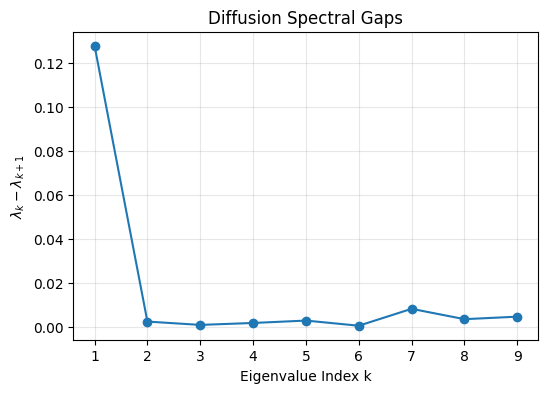

In [5]:
# Spectral gaps: differences between consecutive eigenvalues (helps gauge intrinsic dimensionality)
gaps = lambdas[:-1] - lambdas[1:]
k_idx = np.arange(1, len(lambdas))

plt.figure(figsize=(6, 4))
plt.plot(k_idx, gaps, marker='o')
plt.xlabel('Eigenvalue Index k')
plt.ylabel(r'$\lambda_k - \lambda_{k+1}$')
plt.title('Diffusion Spectral Gaps')
plt.xticks(k_idx)
plt.grid(alpha=0.3)
plt.show()


## Extra analyses
- Spectral gaps of diffusion map eigenvalues.
- 2D/3D embeddings colored by temperature and clustered with K-means.
- Silhouette vs k for K-means on the first three diffusion coords.
- Critical-temperature estimates vs L with 1/(log L)^2 fit and Tc=0.89 line.
- Tc estimates vs epsilon scaling for diffusion-map bandwidth.


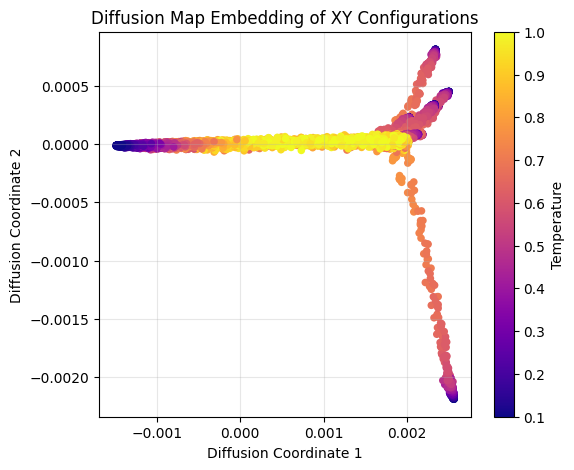

In [5]:
# 2D view of the diffusion map, colored by temperature
plt.figure(figsize=(6, 5))
sc = plt.scatter(embeddings[:, 0], embeddings[:, 1], c=temperatures, cmap='plasma', s=30, edgecolor='none')
plt.xlabel('Diffusion Coordinate 1')
plt.ylabel('Diffusion Coordinate 2')
plt.title('Diffusion Map Embedding of XY Configurations')
cb = plt.colorbar(sc)
cb.set_label('Temperature')
plt.grid(alpha=0.3)
plt.show()


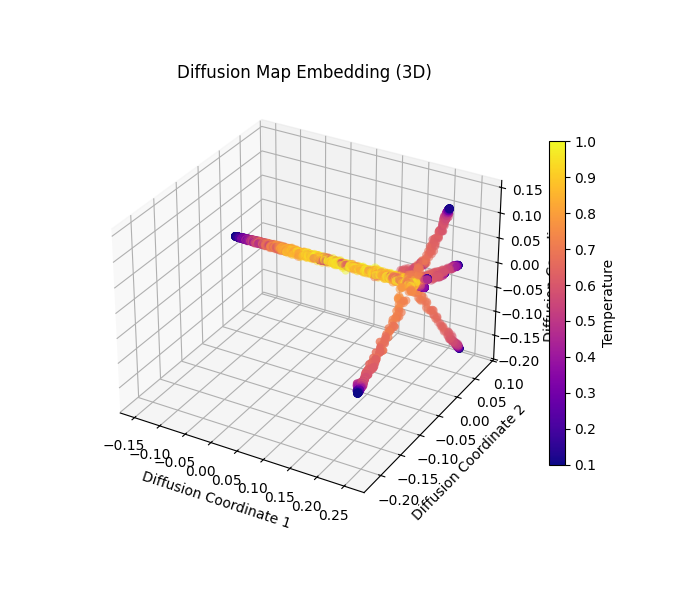

In [6]:
%matplotlib ipympl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# 3D view of the first three diffusion coordinates, color by temperature
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    embeddings[:, 0]*100,
    embeddings[:, 1]*100,
    embeddings[:, 2]*100,
    c=temperatures,
    cmap='plasma',
    s=35,
    edgecolor='none'
)

ax.set_xlabel('Diffusion Coordinate 1')
ax.set_ylabel('Diffusion Coordinate 2')
ax.set_zlabel('Diffusion Coordinate 3')
ax.set_title('Diffusion Map Embedding (3D)')

cbar = fig.colorbar(scatter, ax=ax, shrink=0.7)
cbar.set_label('Temperature')

plt.show()


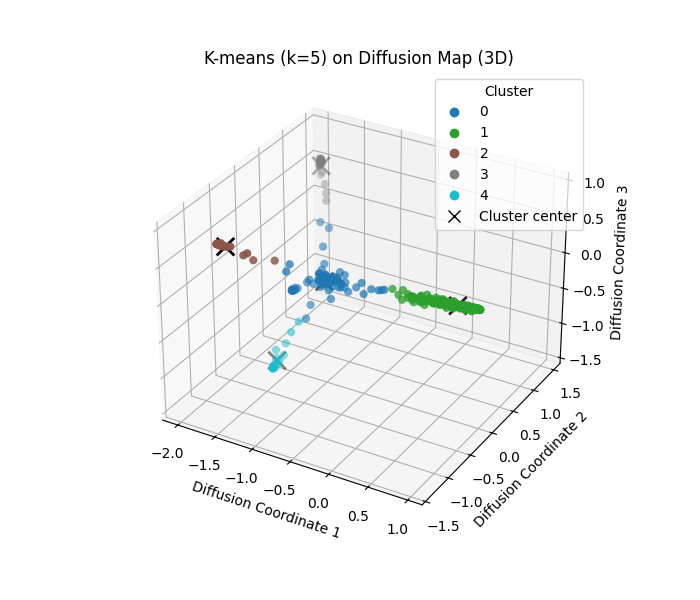

In [16]:
from sklearn.cluster import KMeans
from matplotlib.lines import Line2D

# K-means clustering on the first three coordinates; visualize labels and centers
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init='auto')
labels = kmeans.fit_predict(embeddings[:, :3])
centers = kmeans.cluster_centers_

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    embeddings[:, 0] * 100,
    embeddings[:, 1] * 100,
    embeddings[:, 2] * 100,
    c=labels,
    cmap='tab10',
    s=35,
    edgecolor='none'
)

ax.scatter(
    centers[:, 0] * 100,
    centers[:, 1] * 100,
    centers[:, 2] * 100,
    marker='x',
    s=160,
    linewidths=2,
    c='k',
    label='Cluster center'
)

ax.set_xlabel('Diffusion Coordinate 1')
ax.set_ylabel('Diffusion Coordinate 2')
ax.set_zlabel('Diffusion Coordinate 3')
ax.set_title(f'K-means (k={n_clusters}) on Diffusion Map (3D)')

handles, labels_text = scatter.legend_elements()
handles.append(Line2D([0], [0], marker='x', color='k', linestyle='none', markersize=8, label='Cluster center'))
labels_text.append('Cluster center')
ax.legend(handles, labels_text, title='Cluster')

plt.show()


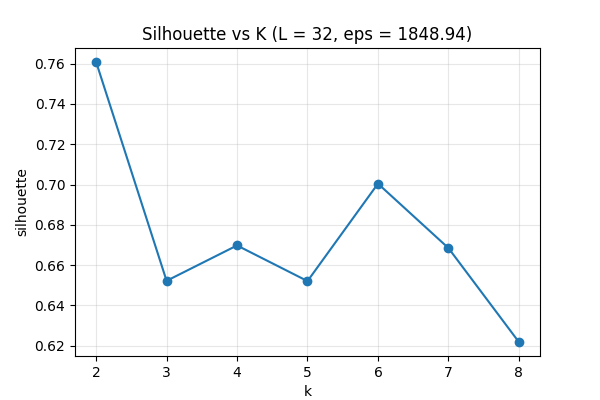

In [7]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

# Sweep k to gauge cluster quality via silhouette on first three coords
k_values = range(2, 9)  # adjust range as needed
X = embeddings[:, :3]
scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init='auto')
    labels = kmeans.fit_predict(X)
    # Silhouette is undefined if only one cluster label appears
    if len(np.unique(labels)) == 1:
        scores.append(np.nan)
    else:
        scores.append(silhouette_score(X, labels))

plt.figure(figsize=(6, 4))
plt.plot(list(k_values), scores, marker='o')
plt.xlabel('k')
plt.ylabel('silhouette')
plt.title('Silhouette vs K (L = 32, eps = {:.2f})'.format(eps))
plt.grid(alpha=0.3)
plt.show()


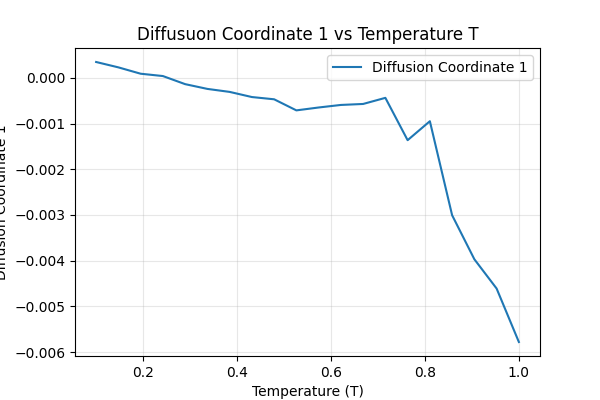

In [17]:
# Track diffusion coordinate 1 as a function of temperature
order = np.argsort(temperatures)
plt.figure(figsize=(6, 4))

unique_temps = sorted(list(set(temperatures)))
average_temp_embedding = {}
for temp in unique_temps:
    average_temp_embedding[temp] = np.mean(embeddings[temperatures == temp, 0])

plt.plot(unique_temps, [average_temp_embedding[temp] for temp in unique_temps], label='Diffusion Coordinate 1')

# plt.plot(temperatures[order], embeddings[order, 1], label='Coord 2')
# plt.plot(temperatures[order], embeddings[order, 2], label='Coord 3')
# plt.plot(temperatures[order], embeddings[order, 3], label='Coord 4')
# plt.plot(temperatures[order], embeddings[order, 4], label='Coord 5')
plt.xlabel('Temperature (T)')
plt.ylabel('Diffusion Coordinate 1')
plt.title('Diffusuon Coordinate 1 vs Temperature T')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


/tmp/ipykernel_233623/2097429834.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


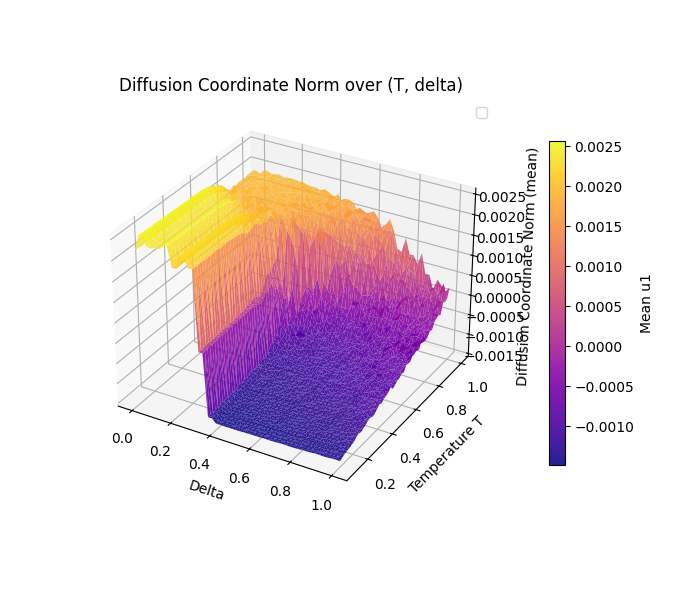

In [11]:
# 3D surface: diffusion coordinate 1 vs temperature and delta
u1 = embeddings[:, 0]
u2 = embeddings[:, 1]
u3 = embeddings[:, 2]
u4 = embeddings[:, 3]


grad = np.sqrt(u1**2 + u2**2 + u3**2 + u4**2)

# Average the first diffusion coordinate for each (T, delta) pair
combo_to_vals = {}
for ui, Ti, di in zip(u1, temperatures, deltas):
    combo_to_vals.setdefault((Ti, di), []).append(ui)

T_vals = np.array([k[0] for k in combo_to_vals.keys()])
delta_vals = np.array([k[1] for k in combo_to_vals.keys()])
u1_mean = np.array([np.mean(v) for v in combo_to_vals.values()])

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')

# Triangulated surface from the (T, delta) points
surf = ax.plot_trisurf(delta_vals, T_vals, u1_mean, cmap='plasma', linewidth=0.2, antialiased=True, alpha=0.9)

# Overlay individual samples for context
# ax.scatter(temperatures, deltas, u1, color='k', s=8, alpha=0.25, label='Samples')

ax.set_xlabel('Delta')
ax.set_ylabel('Temperature T')
ax.set_zlabel('Diffusion Coordinate Norm (mean)')
ax.set_title('Diffusion Coordinate Norm over (T, delta)')
fig.colorbar(surf, ax=ax, shrink=0.7, pad=0.1, label='Mean u1')
ax.legend()
plt.show()


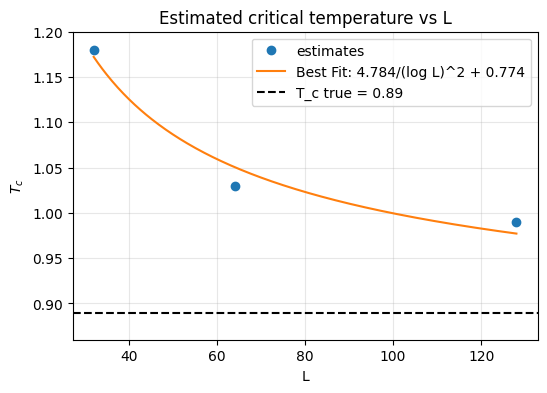

In [87]:
# Finite-size trend: Tc vs L with 1/(log L)^2 fit and true Tc line
L_values = np.array([32, 64, 128], dtype=float)
Tc_values = np.array([1.18, 1.03, 0.99], dtype=float)

# Fit Tc vs x where x = 1 / (log L)^2
x = 1.0 / (np.log(L_values) ** 2)
coeffs = np.polyfit(x, Tc_values, 1)

L_fit = np.linspace(L_values.min(), L_values.max(), 300)
x_fit = 1.0 / (np.log(L_fit) ** 2)
Tc_fit = np.polyval(coeffs, x_fit)

Tc_true = 0.89

plt.figure(figsize=(6, 4))
plt.plot(L_values, Tc_values, 'o', label='estimates')
plt.plot(L_fit, Tc_fit, '-', label=f'Best Fit: {coeffs[0]:.3f}/(log L)^2 + {coeffs[1]:.3f}')
plt.axhline(Tc_true, color='k', linestyle='--', label=f'T_c true = {Tc_true}')
plt.ylim(0.86, 1.2)
plt.xlabel('L')
plt.ylabel(r'$T_c$')
plt.title('Estimated critical temperature vs L')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


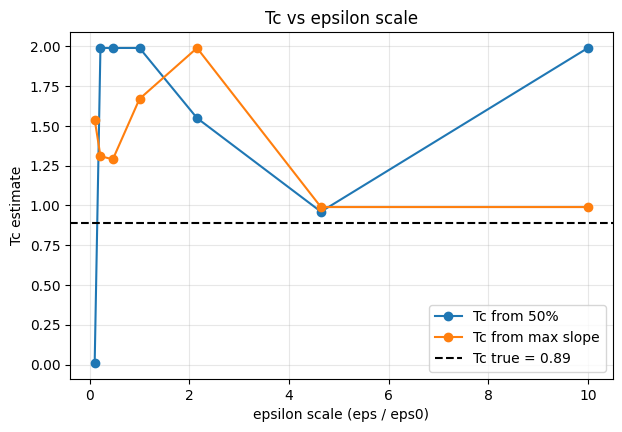

In [92]:
# Sensitivity study: recompute Tc estimates while scaling epsilon in the diffusion map
eps0 = eps  # baseline epsilon from diffusion map
scales = np.logspace(-1, 1, 7)  # 0.1x to 10x
tc_from_50 = []
tc_from_slope = []

def estimate_tc_from_u(u_vals, temps):
    order = np.argsort(temps)
    T_sorted = temps[order]
    u_sorted = u_vals[order]
    # Mean per unique temperature
    uniq_T = np.unique(T_sorted)
    mean_u = np.zeros_like(uniq_T, dtype=float)
    for i, T in enumerate(uniq_T):
        mean_u[i] = u_sorted[T_sorted == T].mean()
    # Normalize to [0,1] for 50% crossing
    mu_min, mu_max = mean_u.min(), mean_u.max()
    if mu_max - mu_min == 0:
        tc_50 = np.nan
    else:
        mu_norm = (mean_u - mu_min) / (mu_max - mu_min)
        tc_50 = np.interp(0.5, mu_norm, uniq_T)
    # Max absolute slope
    deriv = np.gradient(mean_u, uniq_T)
    tc_slope = uniq_T[np.argmax(np.abs(deriv))]
    return tc_50, tc_slope

for scale in scales:
    embeddings_scale, _, _ = diffusion_map_O2_invariant(angles, epsilon=eps0 * scale, n_components=3)
    u_scale = embeddings_scale[:, 0]
    tc50, tc_slope = estimate_tc_from_u(u_scale, temperatures)
    tc_from_50.append(tc50)
    tc_from_slope.append(tc_slope)

Tc_true = 0.89

plt.figure(figsize=(7, 4.5))
plt.plot(scales, tc_from_50, 'o-', label='Tc from 50%')
plt.plot(scales, tc_from_slope, 'o-', label='Tc from max slope')
plt.axhline(Tc_true, color='k', linestyle='--', label=f'Tc true = {Tc_true}')
plt.xlabel('epsilon scale (eps / eps0)')
plt.ylabel('Tc estimate')
plt.title('Tc vs epsilon scale')
plt.grid(alpha=0.3, which='both')
plt.legend()
plt.show()


Pseudo-critical T from derivative: 0.8898
Pseudo-critical T from variance:   0.1000


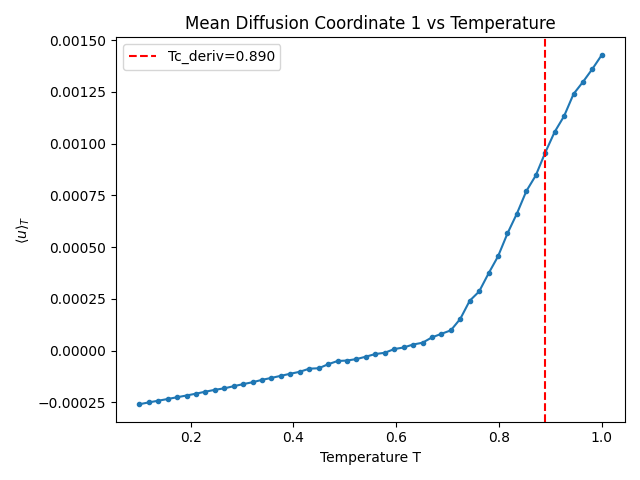

In [12]:
from collections import defaultdict

# Aggregate first diffusion coordinate by temperature to spot pseudo-critical behavior
u = embeddings[:, 0]   # shape: (num_samples,)

# Collect values per discrete temperature
values_by_T = defaultdict(list)
for ui, Ti in zip(u, temperatures):
    values_by_T[Ti].append(ui)

unique_T = np.array(sorted(values_by_T.keys()))
mean_u = np.empty_like(unique_T)
var_u  = np.empty_like(unique_T)

for k, T in enumerate(unique_T):
    arr = np.array(values_by_T[T])
    mean_u[k] = arr.mean()
    var_u[k]  = arr.var(ddof=1)  # use sample variance

# Numerical derivative of mean_u vs T
dmean_dT = np.gradient(mean_u, unique_T)

# Pseudo-critical temperatures from slope peak and variance peak
idx_deriv = np.argmax(np.abs(dmean_dT))
idx_var   = np.argmax(var_u)

Tc_deriv = unique_T[idx_deriv]
Tc_var   = unique_T[idx_var]

print(f"Pseudo-critical T from derivative: {Tc_deriv:.4f}")
print(f"Pseudo-critical T from variance:   {Tc_var:.4f}")

fig, axes = plt.subplots(1, 1, sharex=True)
axes.plot(unique_T, mean_u, marker='o', ls='-', markersize=3)
axes.axvline(Tc_deriv, color='r', ls='--', label=f"Tc_deriv={Tc_deriv:.3f}")
axes.set_ylabel(r"$\langle u \rangle_T$")
axes.set_xlabel('Temperature T')
axes.set_title('Mean Diffusion Coordinate 1 vs Temperature')
axes.legend()

plt.tight_layout()
plt.show()


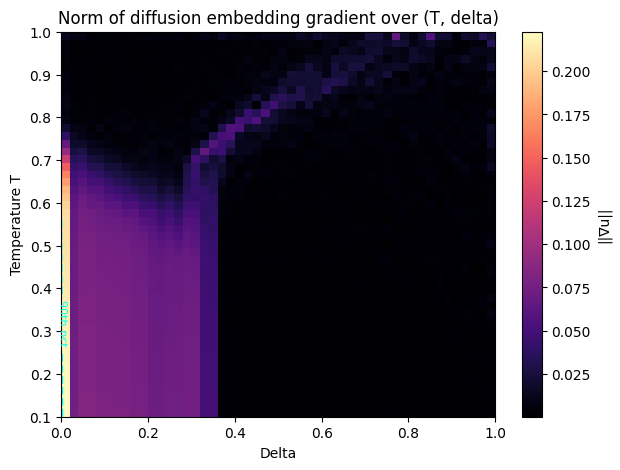

In [29]:

# Gradient norm of diffusion embedding vs temperature and delta
unique_T = np.unique(temperatures)
unique_delta = np.unique(deltas)

# embed_dim = embeddings.shape[1]
embed_dim = 10

mean_embed = np.zeros((unique_T.size, unique_delta.size, embed_dim), dtype=float)
counts = np.zeros((unique_T.size, unique_delta.size), dtype=int)

# Aggregate embeddings on the (T, delta) grid
for emb, T, d in zip(embeddings[:, :(embed_dim)], temperatures, deltas):
    ti = np.searchsorted(unique_T, T)
    di = np.searchsorted(unique_delta, d)
    mean_embed[ti, di] += emb
    counts[ti, di] += 1

if np.any(counts == 0):
    raise ValueError('Missing samples for some (T, delta) pairs.')

mean_embed = mean_embed / counts[..., None]

# Gradients along temperature and delta axes with actual spacing
grad_T, grad_delta = np.gradient(mean_embed, unique_T, unique_delta, axis=(0, 1), edge_order=2)
grad_norm = np.sqrt((grad_T ** 2 + grad_delta ** 2).sum(axis=-1))


# Mark regions where the gradient jumps (top 10%)
threshold = np.percentile(grad_norm, 99)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(
    grad_norm,
    origin='lower',
    aspect='auto',
    extent=(unique_delta.min(), unique_delta.max(), unique_T.min(), unique_T.max()),
    cmap='magma'
)
cs = ax.contour(
    unique_delta,
    unique_T,
    grad_norm,
    levels=[threshold],
    colors='cyan',
    linewidths=1.5,
    linestyles='--'
)
ax.clabel(cs, fmt='90th pct', inline=True, fontsize=8)
ax.set_xlabel('Delta')
ax.set_ylabel('Temperature T')
ax.set_title('Norm of diffusion embedding gradient over (T, delta)')
fig.colorbar(im, ax=ax, label='||∇u||')
plt.show()
